In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False
import os

## 展示每个基因下，不同谱系之间回声非回声差异

In [2]:
seq_dir = '/home/rsun@ZHANGroup.local/hqy_new/CEP_project/data/msa_df_717'
file_list = os.listdir(seq_dir)

file_path = os.path.join(seq_dir, file_list[0])
# gene_name = file_list[0].split('.csv')[0]
gene_name = 'SLC26A5'
data = pd.read_csv(file_path, index_col = 0)   ## 序列信息

meta_df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/metadata/metadata_1.csv', index_col = 0)

idx = meta_df['order_chinese_new'].isin(['鲸目','翼手目','真盲缺目','啮齿目','非洲兽目'])
species_list = meta_df.index[idx]
data = data.loc[species_list,:]
label = meta_df['label'].loc[species_list]
order = meta_df['order_chinese_new'].loc[species_list]
meta_df = meta_df.loc[species_list,:]

assert (data.index == meta_df.index).all()
data.index = meta_df['species_chinese'].values

## 比较两两序列的相似度，得到一个m*m的相似性矩阵，两条序列之间相似度定义为 (seq_1 == seq_2).sum() / data.shape[1]
## 讲这个结果可视化，显示一个m*m的热图，热图按照谱系分成五组，每组内再根据回声非回声分组 
## 在热图边添加双层colorbar显示谱系信息和回声信息。使用红蓝区分回声，使用5种符合科研绘图颜色绘制谱系信息

/tmp/ipykernel_1669777/1538017053.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


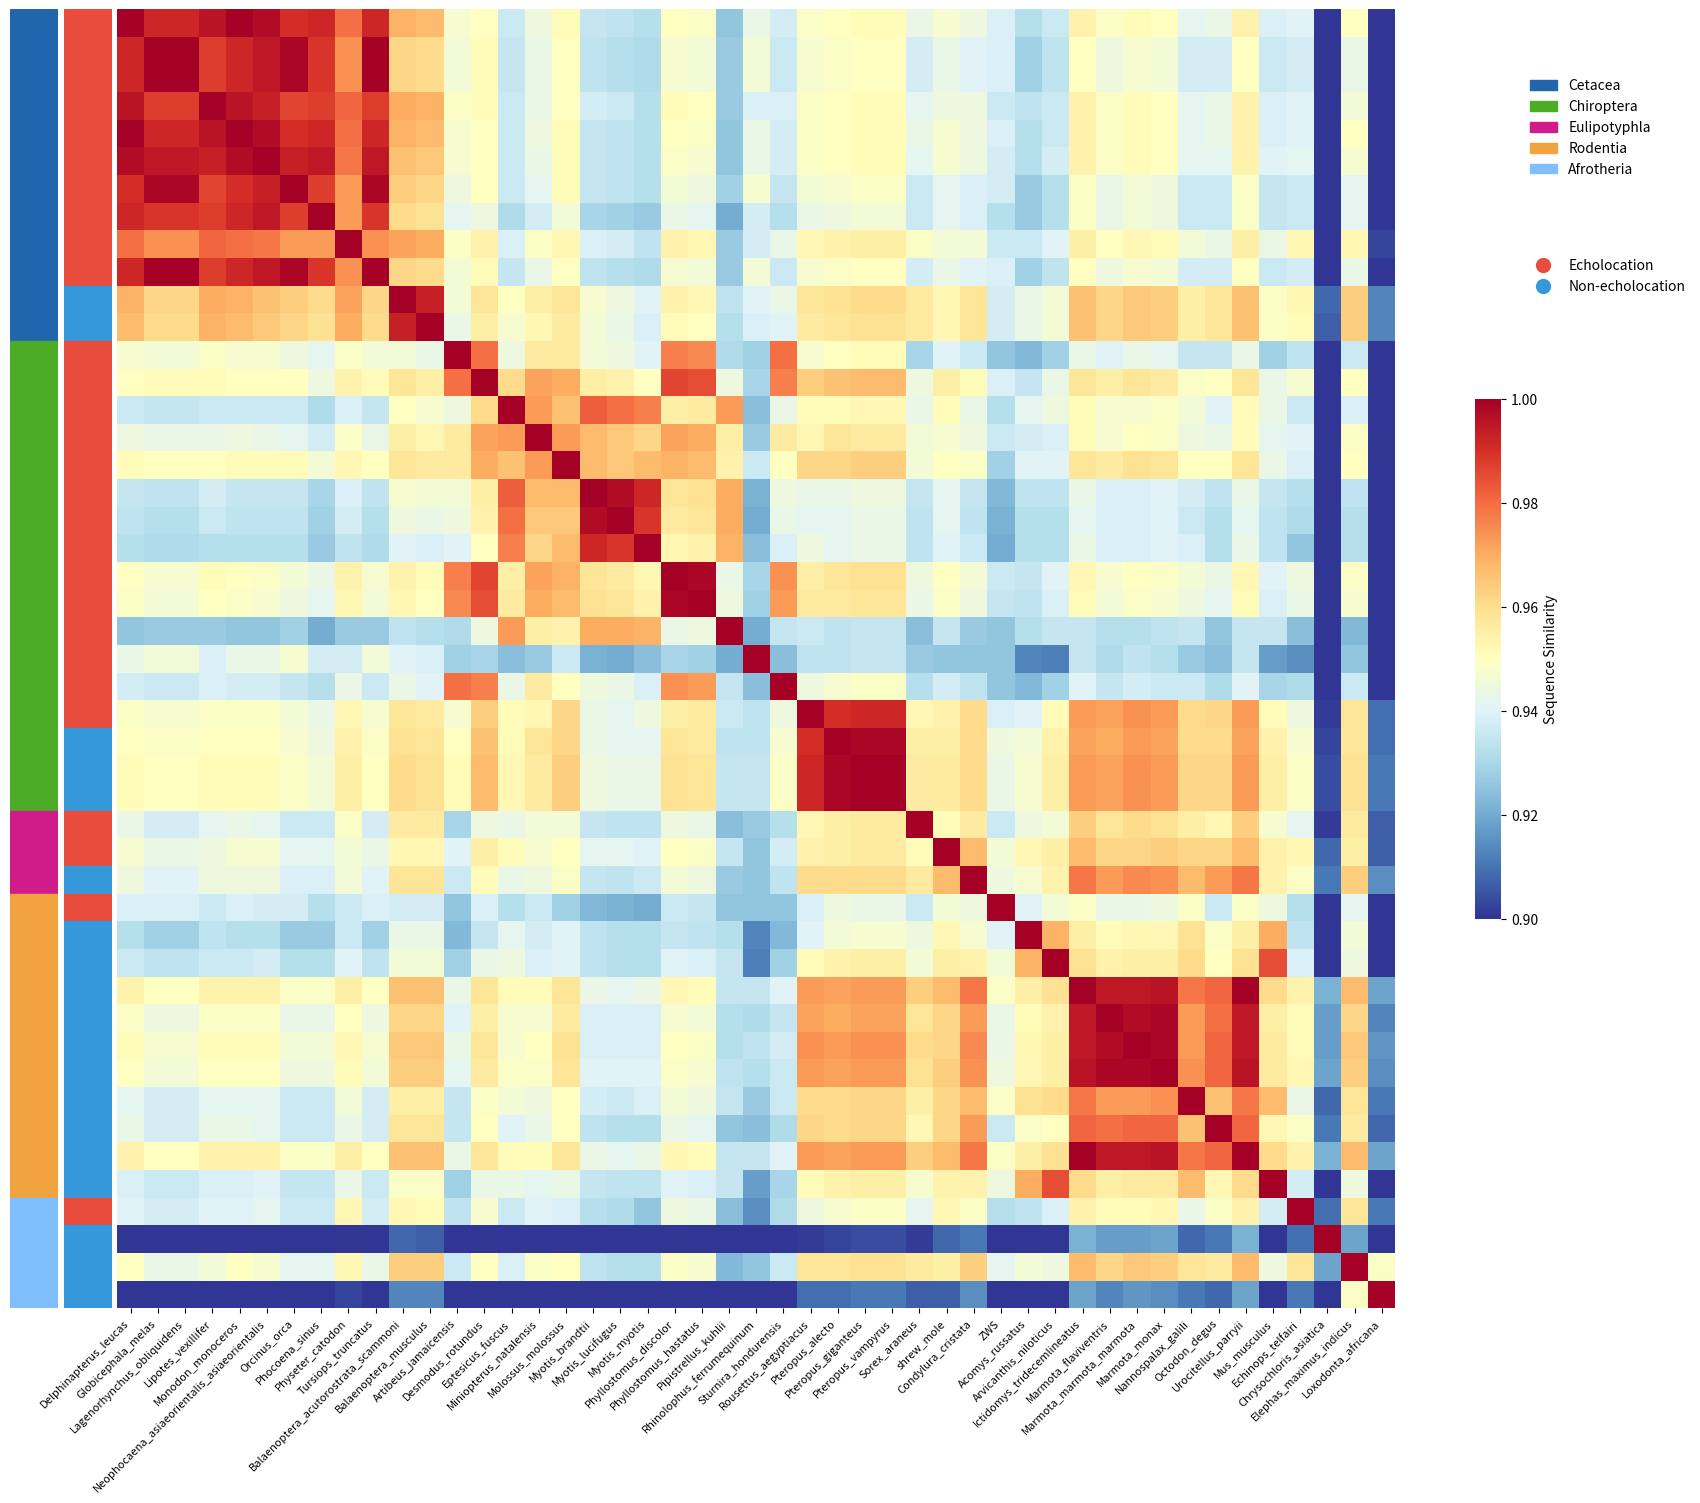

In [3]:


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# 1. 路径设置
seq_dir = '/home/rsun@ZHANGroup.local/hqy_new/data_717/data'
gene_name = 'SLC26A5'
file_path = os.path.join(seq_dir, f'{gene_name}.csv')

# 2. 读取数据
data = pd.read_csv(file_path, index_col=0)
meta_df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/metadata/metadata_1.csv', index_col=0)
meta_df.loc[:,'en_idx'] = meta_df.index.values

# --- 关键对齐点：同步原代码的 Index 替换逻辑 ---
meta_df = meta_df.loc[data.index, :]
# 先统一换成中文名作为 Index，确保后续 remove 操作和排序依据与原版一致
data.index = meta_df['species_chinese'].values
meta_df.index = meta_df['species_chinese'].values





# 3. 英文映射
order_map_en = {
    '鲸目': 'Cetacea',
    '翼手目': 'Chiroptera',
    '真盲缺目': 'Eulipotyphla',
    '啮齿目': 'Rodentia',
    '非洲兽目': 'Afrotheria'
}

# 4. 过滤数据 (此时 Index 已经是中文名)
target_orders = list(order_map_en.keys())
idx = (meta_df['order_chinese_new'].isin(target_orders)) & (meta_df['label'] < 2)
species_list = meta_df.index[idx].to_list()

# 执行原代码中的 remove 操作
for sp in ['大蹄蝠', '大卫鼠耳蝠']:
    if sp in species_list: species_list.remove(sp)

data = data.loc[species_list, :]
meta_df = meta_df.loc[species_list, :]
meta_df['order_en'] = meta_df['order_chinese_new'].map(order_map_en)

# 5. 计算相似度矩阵
n = data.shape[0]
data_values = data.values
sim_matrix_vals = np.zeros((n, n))
for i in range(n):
    sim_matrix_vals[i] = np.sum(data_values[i] == data_values, axis=1) / data.shape[1]

# 此时 sim_matrix 的 index 和 columns 是中文名
sim_matrix = pd.DataFrame(sim_matrix_vals, index=data.index, columns=data.index)

# 6. 排序逻辑 (严格遵循原版：鲸目->翼手目->真盲缺... 且组内按 label 降序)
order_priority_zh = {'鲸目': 0, '翼手目': 1, '真盲缺目': 2, '啮齿目': 3, '非洲兽目': 4}
sort_key = pd.DataFrame({
    'order_zh': meta_df['order_chinese_new'],
    'label': meta_df['label']
}, index=data.index) 

sort_key['order_rank'] = sort_key['order_zh'].map(order_priority_zh)
sort_key = sort_key.sort_values(['order_rank', 'label'], ascending=[True, False])

sorted_species = sort_key.index.tolist()
sim_matrix = sim_matrix.loc[sorted_species, sorted_species]

# --- 翻译点：在绘图前将 Index 从中文翻译为英文 ---
# 假设 meta_df 中有一列 'en_idx' 记录了英文名，如果没有，请确保 meta_df 包含英文信息
# 这里创建一个映射表
zh_to_en_map = meta_df['en_idx'].to_dict() 
# 如果你想手动修改特定的名字（如猪尾鼠），在这里处理映射
# zh_to_en_map['猪尾鼠'] = 'Typhlomys_daloushanensis'

# 重命名矩阵，使其显示为英文但保持原先排好的顺序
sim_matrix_en = sim_matrix.rename(index=zh_to_en_map, columns=zh_to_en_map)
sorted_species_en = sim_matrix_en.index.tolist()

# 7. 颜色配置 (基于英文名获取排序后的 color bar)
order_colors = {
    'Cetacea': '#2166ac',
    'Chiroptera': '#4dac26',
    'Eulipotyphla': '#d01c8b',
    'Rodentia': '#f1a340',
    'Afrotheria': '#7fbfff'
}
# 获取排序后的颜色列表
order_bar = [order_colors[order_map_en[meta_df.loc[s, 'order_chinese_new']]] for s in sorted_species]
label_bar = ['#e74c3c' if meta_df.loc[s, 'label'] == 1.0 else '#3498db' for s in sorted_species]

# 8. 绘图
fig = plt.figure(figsize=(22, 18))
gs = GridSpec(3, 3, width_ratios=[0.03, 0.03, 1], height_ratios=[0.03, 0.03, 1], hspace=0.01, wspace=0.01)

ax_heatmap = fig.add_subplot(gs[2, 2])
ax_row_order = fig.add_subplot(gs[2, 0])
ax_row_label = fig.add_subplot(gs[2, 1])

# 绘制热图
sns.heatmap(sim_matrix_en, 
            ax=ax_heatmap,
            cmap='RdYlBu_r',
            vmin=0.9, vmax=1.0,
            xticklabels=True, 
            yticklabels=False, # 恢复为 True 确认英文名是否正确
            cbar=True,
            cbar_kws={'label': 'Sequence Similarity', 'shrink': 0.4})

ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=8)
ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

# 绘制左侧 colorbar
for i, color in enumerate(order_bar):
    ax_row_order.add_patch(plt.Rectangle((0, n - i - 1), 1, 1, color=color))
ax_row_order.set_xlim(0, 1)
ax_row_order.set_ylim(0, n)
ax_row_order.axis('off')

for i, color in enumerate(label_bar):
    ax_row_label.add_patch(plt.Rectangle((0, n - i - 1), 1, 1, color=color))
ax_row_label.set_xlim(0, 1)
ax_row_label.set_ylim(0, n)
ax_row_label.axis('off')

# 9. 图例 (保持不变)
order_legend = [mpatches.Patch(color=c, label=o) for o, c in order_colors.items()]
label_legend = [
    Line2D([0], [0], marker='o', color='w', label='Echolocation', markerfacecolor='#e74c3c', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Non-echolocation', markerfacecolor='#3498db', markersize=12)
]

fig.legend(handles=order_legend, bbox_to_anchor=(0.81, 0.8), loc='upper left', frameon=False)
fig.legend(handles=label_legend, bbox_to_anchor=(0.81, 0.7), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('prestin_seq.svg', bbox_inches = 'tight')
plt.show()